In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [81]:
# file has .arff extension but content is CSV-style
df = pd.read_csv("D:/TEKWORKS/day17/Autism_Data.arff")
df

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,'18 and more',?,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0,1,0,1,1,0,1,1,1,1,...,f,White-European,no,no,Russia,no,7,'18 and more',Self,YES
700,1,0,0,0,0,0,0,1,0,1,...,m,Hispanic,no,no,Mexico,no,3,'18 and more',Parent,NO
701,1,0,1,1,1,0,1,1,0,1,...,f,?,no,no,Russia,no,7,'18 and more',?,YES
702,1,0,0,1,1,0,1,0,1,1,...,m,'South Asian',no,no,Pakistan,no,6,'18 and more',Self,NO


In [82]:
df.isnull().sum()

A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

A1_Score        Axes(0.125,0.747241;0.133621x0.132759)
A2_Score     Axes(0.285345,0.747241;0.133621x0.132759)
A3_Score      Axes(0.44569,0.747241;0.133621x0.132759)
A4_Score     Axes(0.606034,0.747241;0.133621x0.132759)
A5_Score     Axes(0.766379,0.747241;0.133621x0.132759)
A6_Score        Axes(0.125,0.587931;0.133621x0.132759)
A7_Score     Axes(0.285345,0.587931;0.133621x0.132759)
A8_Score      Axes(0.44569,0.587931;0.133621x0.132759)
A9_Score     Axes(0.606034,0.587931;0.133621x0.132759)
A10_Score    Axes(0.766379,0.587931;0.133621x0.132759)
result          Axes(0.125,0.428621;0.133621x0.132759)
dtype: object

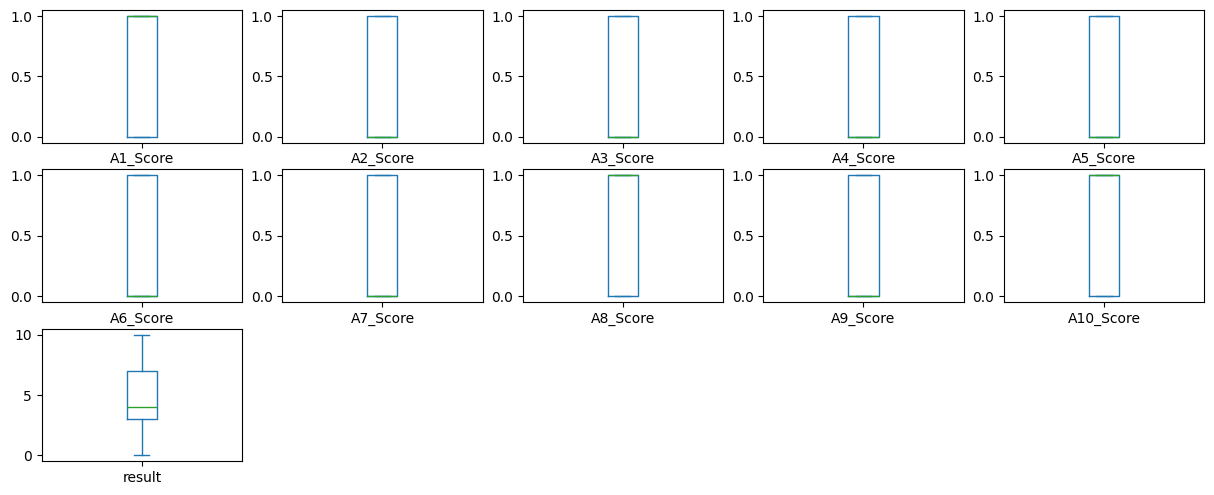

In [83]:
df.plot(kind="box",subplots=True,layout=(5,5),figsize=(15,10))

In [84]:
df.dtypes

A1_Score            int64
A2_Score            int64
A3_Score            int64
A4_Score            int64
A5_Score            int64
A6_Score            int64
A7_Score            int64
A8_Score            int64
A9_Score            int64
A10_Score           int64
age                object
gender             object
ethnicity          object
jundice            object
austim             object
contry_of_res      object
used_app_before    object
result              int64
age_desc           object
relation           object
Class/ASD          object
dtype: object

In [85]:
df["age"]=df["age"].replace("?",0).astype(int)

In [86]:
df["ethnicity"].value_counts(dropna=False)

ethnicity
White-European       233
Asian                123
?                     95
'Middle Eastern '     92
Black                 43
'South Asian'         36
Others                30
Latino                20
Hispanic              13
Pasifika              12
Turkish                6
others                 1
Name: count, dtype: int64

In [ ]:
#one hot encoding by sklearn 
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
ohe.fit(df[["ethnicity"]])
encoded_ethnicity = ohe.transform(df[["ethnicity"]])
encoded_ethnicity_df = pd.DataFrame(encoded_ethnicity, columns=ohe.get_feature_names_out(["ethnicity"])).astype(int)
df=pd.concat([df,encoded_ethnicity_df], axis=1) 
df.drop("ethnicity",axis=1,inplace=True)
df

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,ethnicity_?,ethnicity_Asian,ethnicity_Black,ethnicity_Hispanic,ethnicity_Latino,ethnicity_Others,ethnicity_Pasifika,ethnicity_Turkish,ethnicity_White-European,ethnicity_others
0,1,1,1,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,1,0
1,1,1,0,1,0,0,0,1,0,1,...,0,0,0,0,1,0,0,0,0,0
2,1,1,0,1,1,0,1,1,1,1,...,0,0,0,0,1,0,0,0,0,0
3,1,1,0,1,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,1,0
4,1,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0,1,0,1,1,0,1,1,1,1,...,0,0,0,0,0,0,0,0,1,0
700,1,0,0,0,0,0,0,1,0,1,...,0,0,0,1,0,0,0,0,0,0
701,1,0,1,1,1,0,1,1,0,1,...,1,0,0,0,0,0,0,0,0,0
702,1,0,0,1,1,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0


In [88]:
df.dtypes

A1_Score                        int64
A2_Score                        int64
A3_Score                        int64
A4_Score                        int64
A5_Score                        int64
A6_Score                        int64
A7_Score                        int64
A8_Score                        int64
A9_Score                        int64
A10_Score                       int64
age                             int64
gender                         object
jundice                        object
austim                         object
contry_of_res                  object
used_app_before                object
result                          int64
age_desc                       object
relation                       object
Class/ASD                      object
ethnicity_'Middle Eastern '     int64
ethnicity_'South Asian'         int64
ethnicity_?                     int64
ethnicity_Asian                 int64
ethnicity_Black                 int64
ethnicity_Hispanic              int64
ethnicity_La

In [89]:
df["contry_of_res"].value_counts(dropna=False)

contry_of_res
'United States'           113
'United Arab Emirates'     82
'New Zealand'              81
India                      81
'United Kingdom'           77
                         ... 
Angola                      1
Azerbaijan                  1
Iraq                        1
'Czech Republic'            1
Cyprus                      1
Name: count, Length: 67, dtype: int64

In [90]:
ohe = OneHotEncoder(sparse_output=False)
ohe.fit(df[["contry_of_res"]])
encoded_ethnicity = ohe.transform(df[["contry_of_res"]])
encoded_ethnicity_df = pd.DataFrame(encoded_ethnicity, columns=ohe.get_feature_names_out(["contry_of_res"])).astype(int)
df=pd.concat([df,encoded_ethnicity_df], axis=1) 
df.drop("contry_of_res",axis=1,inplace=True)
df.dtypes

A1_Score                 int64
A2_Score                 int64
A3_Score                 int64
A4_Score                 int64
A5_Score                 int64
                         ...  
contry_of_res_Sweden     int64
contry_of_res_Tonga      int64
contry_of_res_Turkey     int64
contry_of_res_Ukraine    int64
contry_of_res_Uruguay    int64
Length: 98, dtype: object

In [91]:
df["age_desc"].value_counts(dropna=False)

age_desc
'18 and more'    704
Name: count, dtype: int64

In [92]:
df["gender"].replace({"m":1,"f":0},inplace=True)
df["gender"].astype(int)
df["jundice"].replace({"yes":1,"no":0},inplace=True)
df["jundice"].astype(int)
df["austim"].replace({"yes":1,"no":0},inplace=True)
df["austim"].astype(int)
df["used_app_before"].replace({"yes":1,"no":0},inplace=True)
df["used_app_before"].astype(int)
df["age_desc"].replace({"'18 and more'": 18}, inplace=True)
df["age_desc"].astype(int)
df.dtypes

C:\Users\91998\AppData\Local\Temp\ipykernel_23516\1535905077.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["gender"].replace({"m":1,"f":0},inplace=True)
C:\Users\91998\AppData\Local\Temp\ipykernel_23516\1535905077.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["gender"].replace({"m"

A1_Score                 int64
A2_Score                 int64
A3_Score                 int64
A4_Score                 int64
A5_Score                 int64
                         ...  
contry_of_res_Sweden     int64
contry_of_res_Tonga      int64
contry_of_res_Turkey     int64
contry_of_res_Ukraine    int64
contry_of_res_Uruguay    int64
Length: 98, dtype: object

In [93]:
df["age_desc"].value_counts(dropna=False)

age_desc
18    704
Name: count, dtype: int64

In [94]:
df.drop("used_app_before",axis=1,inplace=True)


In [95]:
df["relation"].value_counts(dropna=False)
ohe= OneHotEncoder(sparse_output=False)
ohe.fit(df[["relation"]])
encoded_relation = ohe.transform(df[["relation"]])
encoded_relation_df = pd.DataFrame(encoded_relation, columns=ohe.get_feature_names_out(["relation"])).astype(int)
df=pd.concat([df,encoded_relation_df], axis=1)
df.drop("relation",axis=1,inplace=True)
df.dtypes

A1_Score             int64
A2_Score             int64
A3_Score             int64
A4_Score             int64
A5_Score             int64
                     ...  
relation_?           int64
relation_Others      int64
relation_Parent      int64
relation_Relative    int64
relation_Self        int64
Length: 102, dtype: object

In [96]:
df["Class/ASD"].value_counts(dropna=False)

Class/ASD
NO     515
YES    189
Name: count, dtype: int64

In [97]:
#to get datatype of all columns in for loop
for col in df.columns:
    print(col,":",df[col].dtype)


A1_Score : int64
A2_Score : int64
A3_Score : int64
A4_Score : int64
A5_Score : int64
A6_Score : int64
A7_Score : int64
A8_Score : int64
A9_Score : int64
A10_Score : int64
age : int64
gender : int64
jundice : int64
austim : int64
result : int64
age_desc : int64
Class/ASD : object
ethnicity_'Middle Eastern ' : int64
ethnicity_'South Asian' : int64
ethnicity_? : int64
ethnicity_Asian : int64
ethnicity_Black : int64
ethnicity_Hispanic : int64
ethnicity_Latino : int64
ethnicity_Others : int64
ethnicity_Pasifika : int64
ethnicity_Turkish : int64
ethnicity_White-European : int64
ethnicity_others : int64
contry_of_res_'Costa Rica' : int64
contry_of_res_'Czech Republic' : int64
contry_of_res_'Hong Kong' : int64
contry_of_res_'New Zealand' : int64
contry_of_res_'Saudi Arabia' : int64
contry_of_res_'Sierra Leone' : int64
contry_of_res_'South Africa' : int64
contry_of_res_'Sri Lanka' : int64
contry_of_res_'United Arab Emirates' : int64
contry_of_res_'United Kingdom' : int64
contry_of_res_'United S

In [98]:
from sklearn.model_selection import train_test_split
X = df.drop("Class/ASD", axis=1)
y = df["Class/ASD"]
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

from sklearn.svm import SVC
model = SVC()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
#accuracy
print("accuracy",model.score(X_test, y_test))


accuracy 0.9432624113475178


In [99]:
#training and testing accuracy
print("training accuracy",model.score(X_train, y_train))
print("testing accuracy",model.score(X_test, y_test))

training accuracy 0.9548780487804878
testing accuracy 0.9432624113475178


In [100]:
for cols in df.columns:
    print(cols,":",df[cols].dtype) 

A1_Score : int64
A2_Score : int64
A3_Score : int64
A4_Score : int64
A5_Score : int64
A6_Score : int64
A7_Score : int64
A8_Score : int64
A9_Score : int64
A10_Score : int64
age : int64
gender : int64
jundice : int64
austim : int64
result : int64
age_desc : int64
Class/ASD : object
ethnicity_'Middle Eastern ' : int64
ethnicity_'South Asian' : int64
ethnicity_? : int64
ethnicity_Asian : int64
ethnicity_Black : int64
ethnicity_Hispanic : int64
ethnicity_Latino : int64
ethnicity_Others : int64
ethnicity_Pasifika : int64
ethnicity_Turkish : int64
ethnicity_White-European : int64
ethnicity_others : int64
contry_of_res_'Costa Rica' : int64
contry_of_res_'Czech Republic' : int64
contry_of_res_'Hong Kong' : int64
contry_of_res_'New Zealand' : int64
contry_of_res_'Saudi Arabia' : int64
contry_of_res_'Sierra Leone' : int64
contry_of_res_'South Africa' : int64
contry_of_res_'Sri Lanka' : int64
contry_of_res_'United Arab Emirates' : int64
contry_of_res_'United Kingdom' : int64
contry_of_res_'United S